## A) Import Libraries

In [88]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## B) Collect Data

In [50]:
# read the file
df = pd.read_csv("Chocolate_Sales.csv")
df.head()

,Sales Person,Country,Product,Date,Amount,Boxes Shipped
0,Jehu Rudeforth,UK,Mint Chip Choco,04-01-2022,"$5,320.00",180.0
1,Van Tuxwell,India,85% Dark Bars,01-08-2022,"$7,896.00",94.0
2,Gigi Bohling,India,Peanut Butter Cubes,07-07-2022,"$4,501.00",91.0
3,Jan Morforth,Australia,Peanut Butter Cubes,27-04-2022,"$12,726.00",342.0
4,Jehu Rudeforth,UK,Peanut Butter Cubes,24-02-2022,"$13,685.00",184.0


## C) Data Understanding 

In [51]:
# check datatype and null values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3282 entries, 0 to 3281
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Sales Person   3282 non-null   object 
 1   Country        3282 non-null   object 
 2   Product        3282 non-null   object 
 3   Date           3282 non-null   object 
 4   Amount         3282 non-null   object 
 5   Boxes Shipped  3281 non-null   float64
dtypes: float64(1), object(5)
memory usage: 154.0+ KB


In [52]:
# count null values
df.isnull().sum()

Sales Person     0
Country          0
Product          0
Date             0
Amount           0
Boxes Shipped    1
dtype: int64

In [53]:
# statistical information
df.describe()

,Boxes Shipped
count,3281.000000
mean,164.715331
std,124.013512
min,1.000000
25%,71.000000
50%,137.000000
75%,232.000000
max,778.000000


## D) Data Cleaning

In [54]:
# duplicate check and remove
df.duplicated().sum()

np.int64(0)

In [55]:
# rename column names
df.columns = df.columns.str.lower().str.replace(' ','_')
df.columns 

Index(['sales_person', 'country', 'product', 'date', 'amount',
       'boxes_shipped'],
      dtype='object')

In [56]:
# fill missing value of Boxes Shipped
df['boxes_shipped'] = df['boxes_shipped'].fillna(df['boxes_shipped'].mean())

In [57]:
# date convert into datetime datatype
df['date'] = pd.to_datetime(df['date'], format='mixed')

In [58]:
# amount convert into float datatype
df['amount'] = df['amount'].str.replace('$','').str.replace(',','').astype(float)

In [59]:
# extract year, month, day and weekdays from Date
df['day'] = df['date'].dt.day
df['month'] = df['date'].dt.month
df['year'] = df['date'].dt.year
df['weekdays'] = df['date'].dt.day_name()

In [60]:
# Years of sales
df['year'].unique()

array([2022, 2023, 2024], dtype=int32)

In [61]:
# sales sum by country
df.groupby('country')['amount'].sum().sort_values(ascending=False)

country
Australia      3646444.35
UK             3365388.90
India          3343730.83
USA            3313858.09
Canada         3078495.65
New Zealand    3043654.04
Name: amount, dtype: float64

## E) Exploratory Data Analysis (EDA) for India

In [62]:
# count the number of sales person, products and sum of sales amount in India
sales_india = df.loc[df['country'] == 'India',['sales_person','product','date','amount','boxes_shipped','day','month','year','weekdays']]
print("Count of sales persons : ", len(sales_india['sales_person'].unique()))
print("Count of products : ", len(sales_india['product'].unique()))
print("Sum of sales amount : ", sales_india['amount'].sum())

Count of sales persons :  25
Count of products :  22
Sum of sales amount :  3343730.83


### 1) Sales Performance

In [63]:
# Total number of boxes shipped in India
sales_india['boxes_shipped'].count()

np.int64(552)

In [64]:
# Average sales amount per transaction in India
sales_india['amount'].mean()

np.float64(6057.48338768116)

In [65]:
# Which year highest sales & lowest sales in India
s1 = sales_india[(sales_india['date'] >= '2022-01-01') & (sales_india['date'] <= '2022-12-31')]
s2 = sales_india[(sales_india['date'] >= '2023-01-01') & (sales_india['date'] <= '2023-12-31')]
s3 = sales_india[(sales_india['date'] >= '2024-01-01') & (sales_india['date'] <= '2024-12-31')]
print("Highest sales in 2024 : ",s3['amount'].sum())
print("Lowest sales in 2022 : ",s1['amount'].sum())

Highest sales in 2024 :  1180680.44
Lowest sales in 2022 :  1045800.0


### 2) Monthly Analysis

In [66]:
# Which month generate highest sales in India
print("April : ",sales_india.groupby('month')['amount'].sum().sort_values().tail(1))

April :  month
4    511227.44
Name: amount, dtype: float64


In [67]:
# Which month generate lowest sales in India
print("October : ",sales_india.groupby('month')['amount'].sum().sort_values().head(1))

October :  month
10    51147.24
Name: amount, dtype: float64


In [68]:
# average monthly sales in India
sales_india.groupby('month')['amount'].mean()

month
1      6749.535333
2      4113.547451
3      6230.369778
4      5876.177471
5      6039.720870
6      5591.767083
7      6429.931212
8      6724.256905
9     10177.368889
10     5683.026667
11     5771.533333
12     5017.700556
Name: amount, dtype: float64

### 3) Product Analysis

product
Eclairs                252107.54
Peanut Butter Cubes    247607.78
Smooth Sliky Salty     241770.37
Spicy Special Slims    240993.16
Mint Chip Choco        217420.06
Name: amount, dtype: float64 



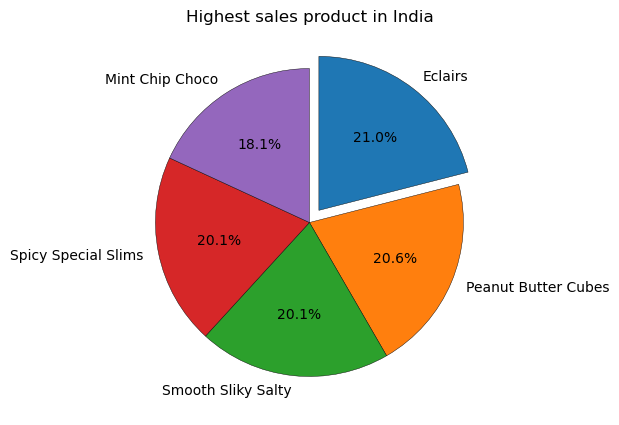

In [69]:
# Top 5 Products by Sales Amount in India with pie chart 
product_sales = sales_india.groupby('product')['amount'].sum().sort_values(ascending=False).head(5)
print(product_sales,"\n")
fig, ax = plt.subplots(figsize=(7,5))
ax.pie(product_sales.values, labels=product_sales.index, autopct='%1.1f%%', counterclock=False, startangle=90, wedgeprops={'edgecolor':'black', 'linewidth':0.3}, explode=[0.1,0,0,0,0])
ax.set_title("Highest sales product in India")
plt.show()

In [70]:
# Lowest 5 Products by Sales Amount in India
sales_india.groupby('product')['amount'].sum().sort_values(ascending=True).head(5)

product
Fruit & Nut Bars       58842.21
Manuka Honey Choco     60325.23
Orange Choco           75316.74
Milk Bars              77299.40
Baker's Choco Chips    88893.04
Name: amount, dtype: float64

product
Spicy Special Slims     6199.0
Eclairs                 6085.0
After Nines             5751.0
Caramel Stuffed Bars    5005.0
White Choc              4951.0
Name: boxes_shipped, dtype: float64 



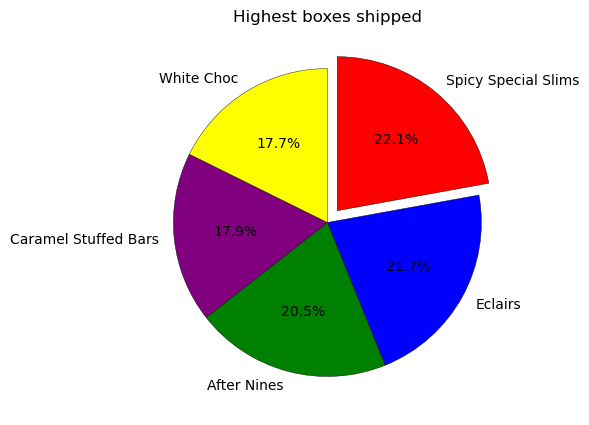

In [71]:
# Top 5 product by Boxes shipped in India with pie chart
boxes_of_products = sales_india.groupby('product')['boxes_shipped'].sum().sort_values(ascending=False).head(5)
print(boxes_of_products,"\n")
colors = ['red','blue','green','purple','yellow']
fig, ax = plt.subplots(figsize=(7,5))
ax.pie(boxes_of_products.values, labels=boxes_of_products.index, autopct='%1.1f%%', colors=colors, counterclock=False, startangle=90, wedgeprops={'edgecolor':'black','linewidth':0.3}, explode=[0.10,0,0,0,0])
ax.set_title("Highest boxes shipped")
plt.show()

In [72]:
# Lowest 5 product by Boxes shipped in India
sales_india.groupby('product')['boxes_shipped'].sum().sort_values(ascending=True).head(5)

product
Smooth Sliky Salty     2208.0
Raspberry Choco        2368.0
Organic Choco Syrup    2706.0
Fruit & Nut Bars       2899.0
Manuka Honey Choco     3019.0
Name: boxes_shipped, dtype: float64

In [73]:
# what percentage of total sales does each product contribute in India
percentage_of_product = ((sales_india.groupby('product')['amount'].sum() / sales_india['amount'].sum()) * 100).sort_values(ascending=False).round(2).head(5)
for product, percentage in percentage_of_product.items():
    print(product," = ",percentage,"%")

Eclairs  =  7.54 %
Peanut Butter Cubes  =  7.41 %
Smooth Sliky Salty  =  7.23 %
Spicy Special Slims  =  7.21 %
Mint Chip Choco  =  6.5 %


### 4) Salesperson Analysis

sales_person
Ches Bonnell    313021.88
Van Tuxwell     277532.36
Oby Sorrel      242478.98
Jan Morforth    218060.20
Brien Boise     194341.81
Name: amount, dtype: float64 



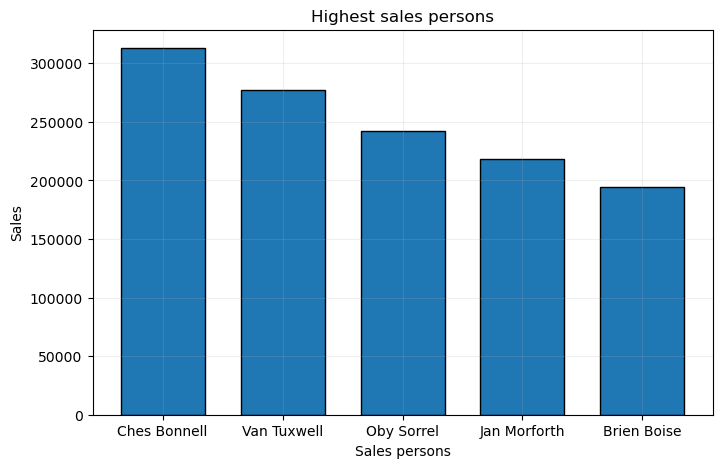

In [74]:
# Top 5 sales person generate highest sales in India with bar chart
person_sales = sales_india.groupby('sales_person')['amount'].sum().sort_values(ascending=False).head(5)
print(person_sales,"\n")
fig, ax = plt.subplots(figsize=(8,5))
ax.bar(person_sales.index, person_sales.values, width=0.7, edgecolor='black')
ax.set_title("Highest sales persons")
ax.set_xlabel("Sales persons")
ax.set_ylabel("Sales")
ax.grid(True,alpha=0.2)
plt.show()

In [75]:
# Lowest 5 sales person generate lowest sales in India
sales_india.groupby('sales_person')['amount'].sum().sort_values(ascending=True).head(5)

sales_person
Madelene Upcott    51917.52
Gigi Bohling       54225.32
Mallorie Waber     55452.40
Kaine Padly        65533.02
Wilone O'Kielt     76700.00
Name: amount, dtype: float64

sales_person
Karlen McCaffrey    6977.0
Kelci Walkden       6336.0
Jan Morforth        6148.0
Van Tuxwell         5294.0
Curtice Advani      5180.0
Name: boxes_shipped, dtype: float64 



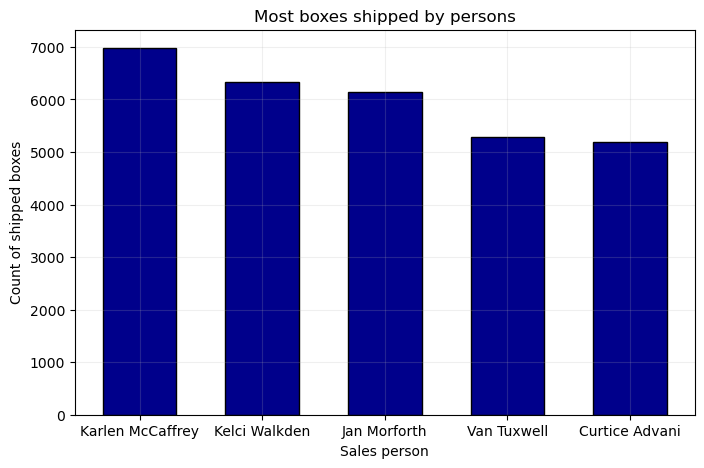

In [76]:
# Top 5 sales person shipped the most boxes in India with bar chart
person_shipped_boxes = sales_india.groupby('sales_person')['boxes_shipped'].sum().sort_values(ascending=False).head(5)
print(person_shipped_boxes,"\n")
fig, ax = plt.subplots(figsize=(8,5))
ax.bar(person_shipped_boxes.index, person_shipped_boxes.values, width=0.6, edgecolor='black', color='darkblue')
ax.set_title("Most boxes shipped by persons")
ax.set_xlabel("Sales person")
ax.set_ylabel("Count of shipped boxes")
ax.grid(True,alpha=0.2)
plt.show()

In [77]:
# what is average sales amount per sales person in India
sales_india.groupby('sales_person')['amount'].mean().sort_values(ascending=False).head()

sales_person
Ches Bonnell           10434.062667
Oby Sorrel              8980.702963
Van Tuxwell             8410.071515
Kaine Padly             7281.446667
Rafaelita Blaksland     6984.924667
Name: amount, dtype: float64

### 5) Yearly Growth Analysis

In [78]:
# what is the year-over-year sales growth percentage in India
yearly_sales = sales_india.groupby('year')['amount'].sum()
yoy_df = pd.DataFrame({
    'sales': yearly_sales,
    'YoY Growth %': round(yearly_sales.pct_change()*100,2)
})
yoy_df

,sales,YoY Growth %
year,,
2022,1045800.00,NaN
2023,1117250.39,6.83
2024,1180680.44,5.68


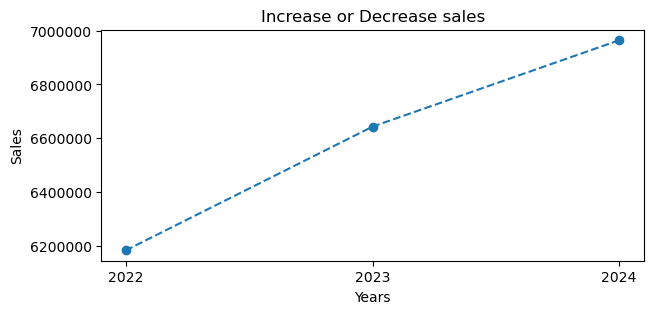

In [79]:
# sales increase or decrease in each year in India with line chart  
sales_year = df.groupby('year')['amount'].sum().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(7,3))
ax.plot(sales_year.index,sales_year.values, marker='o', linestyle='--')
ax.ticklabel_format(style="plain", axis="y")
ax.set_xticks([2022,2023,2024])
ax.set_title("Increase or Decrease sales")
ax.set_xlabel("Years")
ax.set_ylabel("Sales")
plt.show()

In [80]:
# which year showed highest growth in India
sales_india.groupby('year')['amount'].sum().sort_values(ascending=False).head(1)

year
2024    1180680.44
Name: amount, dtype: float64

### 6) Boxes Shipped Analysis

In [81]:
# what is the total number of boxes shipped each year in India
sales_india.groupby('year')['boxes_shipped'].sum()

year
2022    29470.0
2023    30214.0
2024    30284.0
Name: boxes_shipped, dtype: float64

In [82]:
# Which year had highest number of boxes shipped in India
sales_india.groupby('year')['boxes_shipped'].sum().sort_values(ascending=False).head(1)

year
2024    30284.0
Name: boxes_shipped, dtype: float64

In [83]:
# is there relationship between boxes shipped and sales amount in India
print(sales_india.groupby('year')[['boxes_shipped','amount']].sum())
print("\nYES their is relationship between boxes shipped and sales amount in India.")

      boxes_shipped      amount
year                           
2022        29470.0  1045800.00
2023        30214.0  1117250.39
2024        30284.0  1180680.44

YES their is relationship between boxes shipped and sales amount in India.


### 7) Country Filter (Focus on India)

In [84]:
# what percentage of overall company sales comes from India
india_sales = sales_india['amount'].sum()
total_sales = df['amount'].sum()
percentage_of_india = (india_sales / total_sales) *100
print("Company sales from India :",round(percentage_of_india,2),"%")

Company sales from India : 16.89 %


India sales : 3343730.83
UK sales : 3365388.9
Australia sales : 3646444.35 



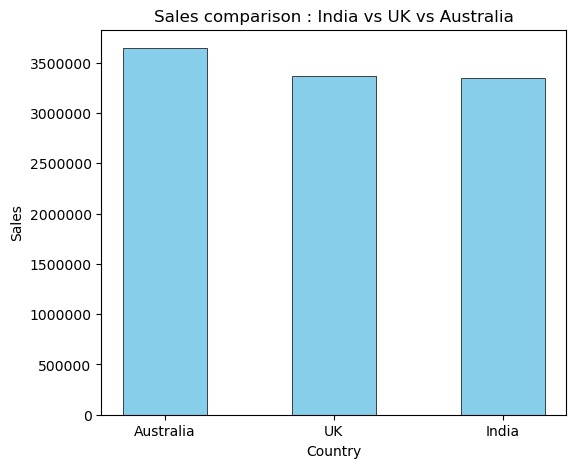

In [85]:
# How does india's sales compare with the UK and Australia 
india_sales = sales_india['amount'].sum()
uk_sales = df[df['country']=='UK']['amount'].sum()
australia_sales = df[df['country']=='Australia']['amount'].sum()
print("India sales :", india_sales)
print("UK sales :", round(uk_sales,2))
print("Australia sales :", australia_sales,"\n")

country_sales = df[df['country'].isin(['India','UK','Australia'])].groupby('country')['amount'].sum().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(6,5))
ax.ticklabel_format(style="plain", axis="y")
ax.bar(country_sales.index, country_sales.values, color='skyblue', width=0.5, edgecolor='black', linewidth=0.5)
ax.set_title("Sales comparison : India vs UK vs Australia")
ax.set_xlabel("Country")
ax.set_ylabel("Sales")
plt.show()

In [86]:
# which product performs best in india compared to other countries
sales_india.groupby('product')['amount'].sum().sort_values(ascending=False).head(1)

product
Eclairs    252107.54
Name: amount, dtype: float64

## F) Save Cleaned Data

In [87]:
# cleaned data save in .csv format
df.to_csv("Cleaned_Chocolate_Sales.csv", index=False)